In [143]:
#!uv pip install pyarrow
#!uv pip install nbformat
#!uv pip install gensim

In [165]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import plotly.express as px
from collections import Counter
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
import gensim.downloader as api

In [46]:
df = pd.read_csv("data/chinese-tea-dataset.csv")

In [47]:
df

,id,name_en,name_zh,category,region,caffeine_level,body,oxidation_level,flavor_primary,description_brief,tier
0,alishan-oolong,Alishan High Mountain Oolong,阿里山乌龙,Oolong Tea,Alishan,moderate,medium,0.20,"floral,butter,cream",Lightly oxidized oolong from Taiwan's Alishan ...,1
1,anji-bai-cha,Anji Bai Cha (Anji White Tea),安吉白茶,Green Tea,Anji County,low,light,0.02,"umami,chestnut,bamboo","A unique green tea (not white, despite the nam...",1
2,bai-hao-yinzhen,Bai Hao Yin Zhen (Silver Needle),白毫银针,White Tea,Fuding,low,light,0.08,"melon,honey,hay","The highest grade of white tea, made exclusive...",1
3,bai-mudan,Bai Mudan (White Peony),白牡丹,White Tea,Fuding,low,light-medium,0.10,"floral,honey,hay","White tea featuring one bud and two leaves, of...",1
4,biluochun,Biluochun (Green Snail Spring),碧螺春,Green Tea,Dongting Mountain,moderate,light,0.02,"fruity,floral,fresh",Prized spring green tea from Dongting Mountain...,1
...,...,...,...,...,...,...,...,...,...,...,...
131,zhi-lan-xiang,Zhi Lan Xiang (Orchid Fragrance),芝兰香,Oolong Tea,Phoenix Mountain,moderate,medium,0.45,"orchid,floral,sweet",A classic dancong variety prized for its pure ...,2
132,zhu-ye-qing,Zhu Ye Qing (Bamboo Leaf Green),竹叶青,Green Tea,Mount Emei,moderate,light,0.02,"fresh,vegetal,sweet",Premium green tea from Mount Emei in Sichuan. ...,2
133,lotus-green-tea,Lotus Green Tea,莲花绿茶,Scented Tea,Zhejiang,low,light,0.03,"lotus,fresh,floral","Green tea scented with lotus flowers. Fresh, f...",3
134,magnolia-oolong,Magnolia Oolong,玉兰乌龙,Scented Tea,Fujian,moderate,medium,0.30,"magnolia,creamy,floral","Oolong scented with magnolia flowers. Creamy, ...",3


In [58]:
mask = (df['name_en'] == "Huangjin Gui") | (df['name_en'] == "Shui Jin Gui") | (df['name_en'] == "Tanyang Gongfu") | (df['name_en'] == "Yue Guang Bai (Moonlight White)") | (df['name_en'] == "Yingde Hong")
df = df[~mask]

In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 131 entries, 0 to 135
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 131 non-null    object 
 1   name_en            131 non-null    object 
 2   name_zh            131 non-null    object 
 3   category           131 non-null    object 
 4   region             131 non-null    object 
 5   caffeine_level     131 non-null    object 
 6   body               131 non-null    object 
 7   oxidation_level    131 non-null    float64
 8   flavor_primary     131 non-null    object 
 9   description_brief  131 non-null    object 
 10  tier               131 non-null    int64  
dtypes: float64(1), int64(1), object(9)
memory usage: 12.3+ KB


In [60]:
category = df['category'].value_counts()

In [61]:
caffeine = df['caffeine_level'].value_counts()

In [62]:
body = df['body'].value_counts()

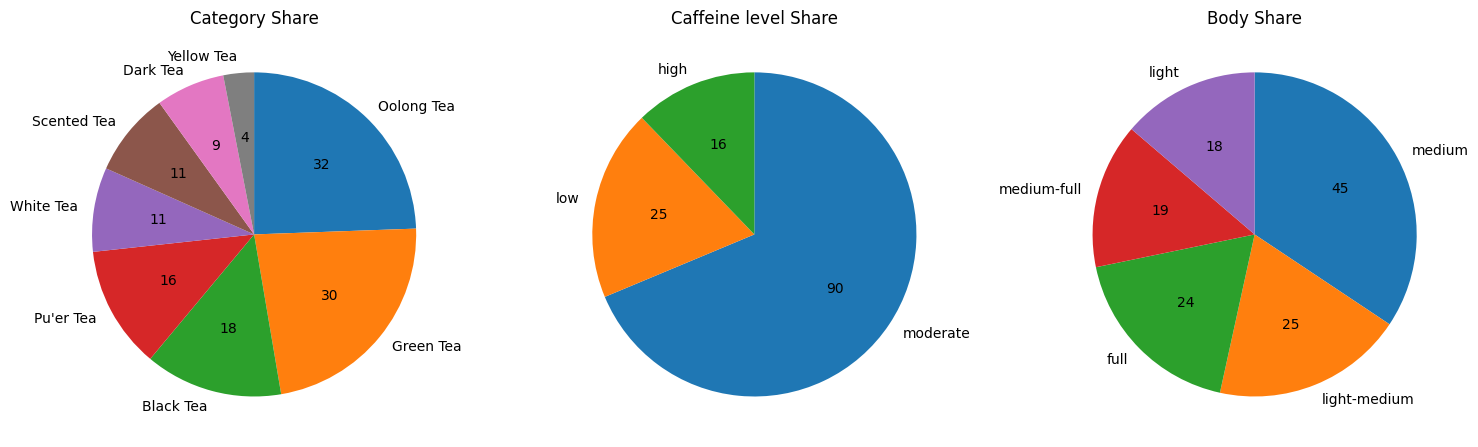

In [63]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

#Category
axes[0].pie(category, labels=category.index, autopct=lambda pct: f"{int(round(pct * category.sum() / 100))}", startangle=90, counterclock=False)
axes[0].set_title('Category Share')

#Caffeine level
axes[1].pie(caffeine, labels=caffeine.index, autopct=lambda pct: f"{int(round(pct * category.sum() / 100))}", startangle=90, counterclock=False)
axes[1].set_title('Caffeine level Share')

#Body
axes[2].pie(body, labels=body.index, autopct=lambda pct: f"{int(round(pct * category.sum() / 100))}", startangle=90, counterclock=False)
axes[2].set_title('Body Share')

plt.tight_layout()
plt.show()

- Encoding
- reduce dimation by using PCA

In [64]:
df = df.set_index('name_en')

In [65]:
df.columns

Index(['id', 'name_zh', 'category', 'region', 'caffeine_level', 'body',
       'oxidation_level', 'flavor_primary', 'description_brief', 'tier'],
      dtype='object')

In [66]:
drop = ['id', 'name_zh','region', 'oxidation_level', 'flavor_primary', 'description_brief', 'tier']
df_pca = df.drop(columns=drop)

In [67]:
df_pca

,category,caffeine_level,body
name_en,,,
Alishan High Mountain Oolong,Oolong Tea,moderate,medium
Anji Bai Cha (Anji White Tea),Green Tea,low,light
Bai Hao Yin Zhen (Silver Needle),White Tea,low,light
Bai Mudan (White Peony),White Tea,low,light-medium
Biluochun (Green Snail Spring),Green Tea,moderate,light
...,...,...,...
Zhi Lan Xiang (Orchid Fragrance),Oolong Tea,moderate,medium
Zhu Ye Qing (Bamboo Leaf Green),Green Tea,moderate,light
Lotus Green Tea,Scented Tea,low,light


### Ordinal Encoder

In [68]:
caffeine_cat = ["low", "moderate", "high"]
body_cat = ["light", "light-medium", "medium", "medium-full", "full"]

In [69]:
ordinal_encoder = OrdinalEncoder(categories=[caffeine_cat,body_cat])
ordinal_encoder.fit(df_pca[["caffeine_level", "body"]])

OrdinalEncoder(categories=[['low', 'moderate', 'high'],
                           ['light', 'light-medium', 'medium', 'medium-full',
                            'full']])

In [70]:
df_pca[["caffeine_level", "body"]] = ordinal_encoder.transform(df_pca[["caffeine_level", "body"]])
df_pca

,category,caffeine_level,body
name_en,,,
Alishan High Mountain Oolong,Oolong Tea,1.0,2.0
Anji Bai Cha (Anji White Tea),Green Tea,0.0,0.0
Bai Hao Yin Zhen (Silver Needle),White Tea,0.0,0.0
Bai Mudan (White Peony),White Tea,0.0,1.0
Biluochun (Green Snail Spring),Green Tea,1.0,0.0
...,...,...,...
Zhi Lan Xiang (Orchid Fragrance),Oolong Tea,1.0,2.0
Zhu Ye Qing (Bamboo Leaf Green),Green Tea,1.0,0.0
Lotus Green Tea,Scented Tea,0.0,0.0


### OneHot Encoder

In [71]:
# Check unique values for category
print(f"The unique values for 'Alley' are {df_pca.category.unique()}")

The unique values for 'Alley' are ['Oolong Tea' 'Green Tea' 'White Tea' "Pu'er Tea" 'Black Tea'
 'Scented Tea' 'Yellow Tea' 'Dark Tea']


In [72]:
ohe = OneHotEncoder(sparse_output=False)
ohe.fit(df_pca[["category"]])

OneHotEncoder(sparse_output=False)

In [73]:
df_pca

,category,caffeine_level,body
name_en,,,
Alishan High Mountain Oolong,Oolong Tea,1.0,2.0
Anji Bai Cha (Anji White Tea),Green Tea,0.0,0.0
Bai Hao Yin Zhen (Silver Needle),White Tea,0.0,0.0
Bai Mudan (White Peony),White Tea,0.0,1.0
Biluochun (Green Snail Spring),Green Tea,1.0,0.0
...,...,...,...
Zhi Lan Xiang (Orchid Fragrance),Oolong Tea,1.0,2.0
Zhu Ye Qing (Bamboo Leaf Green),Green Tea,1.0,0.0
Lotus Green Tea,Scented Tea,0.0,0.0


In [74]:
df_pca[ohe.get_feature_names_out()] = ohe.transform(df_pca[["category"]])
df_pca = df_pca.drop(columns=["category"])

df_pca

,caffeine_level,body,category_Black Tea,category_Dark Tea,category_Green Tea,category_Oolong Tea,category_Pu'er Tea,category_Scented Tea,category_White Tea,category_Yellow Tea
name_en,,,,,,,,,,
Alishan High Mountain Oolong,1.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
Anji Bai Cha (Anji White Tea),0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
Bai Hao Yin Zhen (Silver Needle),0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
Bai Mudan (White Peony),0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
Biluochun (Green Snail Spring),1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
Zhi Lan Xiang (Orchid Fragrance),1.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
Zhu Ye Qing (Bamboo Leaf Green),1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
Lotus Green Tea,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


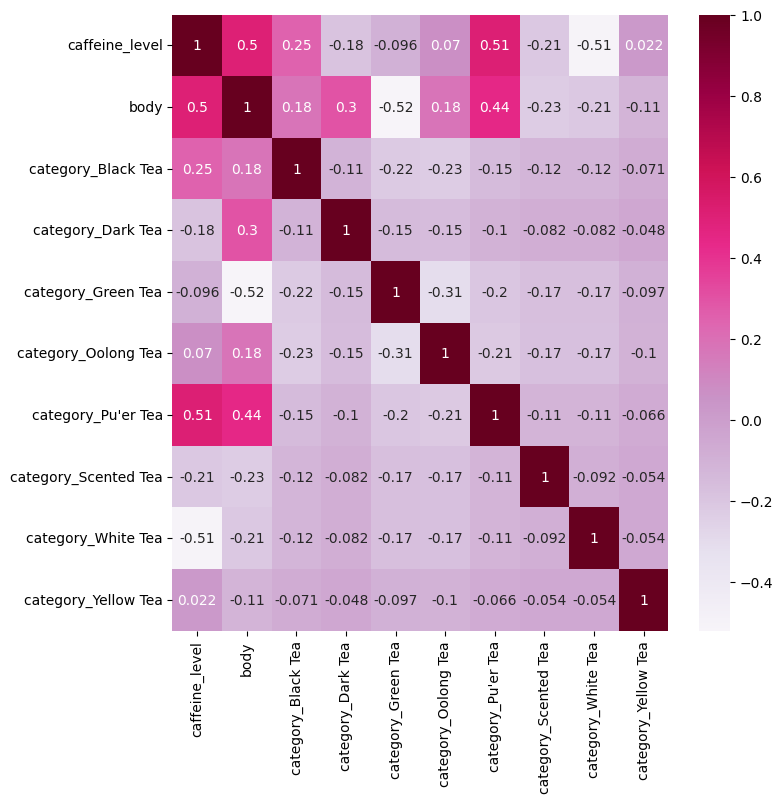

In [75]:
plt.figure(figsize=(8,8))
sns.heatmap(df_pca.corr(),
            annot=True,
            annot_kws={'fontsize':10},
            cmap='PuRd');

In [76]:
#fig = px.scatter_3d(df_pca,
#                    x = 'caffeine_level',
#                    y = 'category_Black Tea',
#                    z = 'category_White Tea',
#                    opacity=0.7, width=500, height=500
#           )
#fig.show()

### PCA

In [77]:
cols = df_pca.columns

In [78]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_pca)
scaled_df = pd.DataFrame(X_scaled, columns=cols, index=df_pca.index)
scaled_df

,caffeine_level,body,category_Black Tea,category_Dark Tea,category_Green Tea,category_Oolong Tea,category_Pu'er Tea,category_Scented Tea,category_White Tea,category_Yellow Tea
name_en,,,,,,,,,,
Alishan High Mountain Oolong,0.123741,-0.036027,-0.399114,-0.271607,-0.545004,1.758906,-0.373002,-0.302765,-0.302765,-0.177471
Anji Bai Cha (Anji White Tea),-1.677382,-1.609211,-0.399114,-0.271607,1.834848,-0.568535,-0.373002,-0.302765,-0.302765,-0.177471
Bai Hao Yin Zhen (Silver Needle),-1.677382,-1.609211,-0.399114,-0.271607,-0.545004,-0.568535,-0.373002,-0.302765,3.302891,-0.177471
Bai Mudan (White Peony),-1.677382,-0.822619,-0.399114,-0.271607,-0.545004,-0.568535,-0.373002,-0.302765,3.302891,-0.177471
Biluochun (Green Snail Spring),0.123741,-1.609211,-0.399114,-0.271607,1.834848,-0.568535,-0.373002,-0.302765,-0.302765,-0.177471
...,...,...,...,...,...,...,...,...,...,...
Zhi Lan Xiang (Orchid Fragrance),0.123741,-0.036027,-0.399114,-0.271607,-0.545004,1.758906,-0.373002,-0.302765,-0.302765,-0.177471
Zhu Ye Qing (Bamboo Leaf Green),0.123741,-1.609211,-0.399114,-0.271607,1.834848,-0.568535,-0.373002,-0.302765,-0.302765,-0.177471
Lotus Green Tea,-1.677382,-1.609211,-0.399114,-0.271607,-0.545004,-0.568535,-0.373002,3.302891,-0.302765,-0.177471


In [79]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

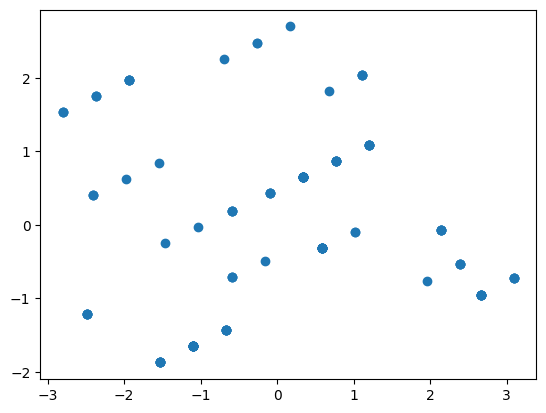

In [80]:
plt.scatter(X_pca[:, 0], X_pca[:, 1])
plt.show()

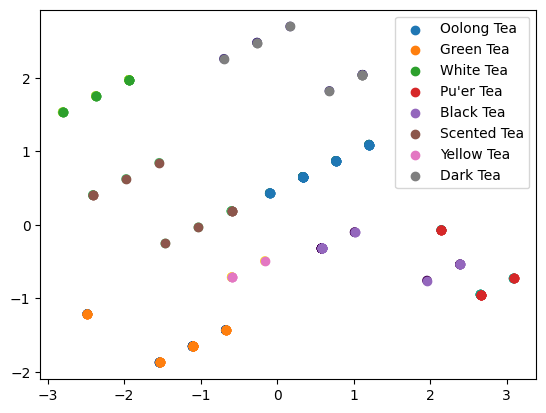

In [81]:
le = LabelEncoder()
category_colors = le.fit_transform(df["category"])

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=category_colors)
for cat in df["category"].unique():
    mask = df["category"] == cat
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=cat)

plt.legend()
plt.show()

#### X axis
- small means low caffeine, light body
- big means high caffeine, full body

#### Y axis
- 

In [82]:
pca.explained_variance_ratio_

array([0.24069618, 0.14579175])

not compressed well

In [83]:
pca.components_

array([[ 0.52482255,  0.54983981,  0.18391861,  0.05147548, -0.30151893,
         0.12448254,  0.40415516, -0.17834549, -0.28798026, -0.03565091],
       [-0.36535753,  0.2798445 , -0.10109858,  0.4122419 , -0.59113594,
         0.29098043, -0.15894234,  0.05921547,  0.3724782 , -0.08010098]])

In [84]:
df_pca.columns

Index(['caffeine_level', 'body', 'category_Black Tea', 'category_Dark Tea',
       'category_Green Tea', 'category_Oolong Tea', 'category_Pu'er Tea',
       'category_Scented Tea', 'category_White Tea', 'category_Yellow Tea'],
      dtype='object')

Check five similar teas of "Alishan High Mountain Oolong"

In [85]:
ex = scaled_df.loc[['Alishan High Mountain Oolong']]

In [86]:
cos_sim = cosine_similarity(ex, scaled_df)

In [87]:
similarities = pd.Series(cos_sim[0], index=scaled_df.index)
top5 = similarities.sort_values(ascending=False)[1:6]
print(top5)

name_en
Ben Shan                1.0
Mi Lan Xiang Dancong    1.0
Shan Lin Xi             1.0
Qi Lan Xiang Dancong    1.0
Zhangping Shuixian      1.0
dtype: float64


All oolong

### How dupulicated?

In [88]:
df.groupby(["category", "body", "caffeine_level"]).size()

category     body          caffeine_level
Black Tea    full          high               4
             medium        moderate          11
             medium-full   high               1
                           moderate           2
Dark Tea     full          low                1
                           moderate           4
             medium        low                1
             medium-full   low                2
                           moderate           1
Green Tea    light         low                5
                           moderate           6
             light-medium  moderate          13
             medium        moderate           6
Oolong Tea   full          moderate           6
             light-medium  moderate           4
             medium        moderate          16
             medium-full   moderate           6
Pu'er Tea    full          high               4
                           moderate           5
             medium-full   high               

### Explore Flavor

In [89]:
df.columns

Index(['id', 'name_zh', 'category', 'region', 'caffeine_level', 'body',
       'oxidation_level', 'flavor_primary', 'description_brief', 'tier'],
      dtype='object')

In [90]:
flavor_list = sorted(df['flavor_primary'].str.split(",").explode().unique().tolist())

In [91]:
flavor_list

['aged',
 'almond',
 'apricot',
 'astringent',
 'balanced',
 'bamboo',
 'betel nut',
 'bitter',
 'bitter-sweet',
 'bold',
 'bright',
 'brisk',
 'butter',
 'camphor',
 'caramel',
 'chestnut',
 'chrysanthemum',
 'cinnamon',
 'citrus',
 'cocoa',
 'cooling',
 'cream',
 'creamy',
 'cucumber',
 'dark chocolate',
 'dates',
 'delicate',
 'dried-fruit',
 'earth',
 'earthy',
 'elegant',
 'evolving',
 'floral',
 'fragrant',
 'fresh',
 'fruit',
 'fruity',
 'full',
 'gardenia',
 'grass',
 'grassy',
 'hay',
 'herbs',
 'honey',
 'honey orchid',
 'jasmine',
 'jujube',
 'leather',
 'light',
 'lima bean',
 'long',
 'longan',
 'lotus',
 'magnolia',
 'malt',
 'malty',
 'marine',
 'mellow',
 'melon',
 'mild',
 'mineral',
 'muscatel',
 'mushroom',
 'nutty',
 'orchid',
 'osmanthus',
 'pear',
 'pine',
 'plum',
 'refreshing',
 'roasted',
 'robust',
 'rose',
 'silky',
 'smoke',
 'smoky',
 'smooth',
 'soothing',
 'sticky-rice',
 'stone fruit',
 'subtle-roast',
 'sweet',
 'sweet corn',
 'sweet pea',
 'sweet potat

In [92]:
flavor_list_dup = sorted(df['flavor_primary'].str.split(",").explode().tolist())

Counter(flavor_list_dup)

Counter({'sweet': 59,
         'floral': 45,
         'honey': 23,
         'chestnut': 14,
         'earth': 12,
         'orchid': 12,
         'vegetal': 12,
         'smooth': 10,
         'mineral': 9,
         'creamy': 8,
         'fresh': 7,
         'fruit': 7,
         'malt': 7,
         'mellow': 7,
         'cocoa': 6,
         'jasmine': 5,
         'nutty': 5,
         'roasted': 5,
         'fruity': 4,
         'hay': 4,
         'light': 4,
         'plum': 4,
         'robust': 4,
         'wood': 4,
         'apricot': 3,
         'bitter': 3,
         'bold': 3,
         'bright': 3,
         'brisk': 3,
         'butter': 3,
         'cooling': 3,
         'delicate': 3,
         'earthy': 3,
         'melon': 3,
         'osmanthus': 3,
         'refreshing': 3,
         'silky': 3,
         'smoky': 3,
         'wine': 3,
         'aged': 2,
         'astringent': 2,
         'cinnamon': 2,
         'citrus': 2,
         'dates': 2,
         'dried-fruit': 2,
  

Apply all-MiniLM-L6-v2

In [94]:
model = SentenceTransformer("all-MiniLM-L6-v2")

In [105]:
encoded = model.encode(flavor_list)

In [107]:
encoded.shape

(94, 384)

In [130]:
floral_idx = flavor_list.index("floral")
jasmine_idx = flavor_list.index("jasmine")


In [115]:
floral_vec = encoded[floral_idx].reshape(1, -1)
jasmine_vec = encoded[jasmine_idx].reshape(1, -1)

cosine_similarity(floral_vec, jasmine_vec)

array([[0.3645466]], dtype=float32)

In [128]:
idx1 = flavor_list.index("chestnut")
idx2 = flavor_list.index("smoke")
chestnut_vec = encoded[idx1].reshape(1, -1)
smoke_vec = encoded[idx2].reshape(1, -1)

cosine_similarity(chestnut_vec, smoke_vec)

array([[0.29073533]], dtype=float32)

In [129]:
similarity_matrix = cosine_similarity(encoded)
similarity_matrix.shape

(94, 94)

In [131]:
sim_df = pd.DataFrame(similarity_matrix, index=flavor_list, columns=flavor_list)
sim_pairs = sim_df.unstack()

In [136]:
sim_df

,aged,almond,apricot,astringent,balanced,bamboo,betel nut,bitter,bitter-sweet,bold,...,sweet potato,thick,toasty,umami,vegetal,velvet,white peach,wine,wood,woody
aged,1.000000,0.213613,0.152027,0.149226,0.227213,0.227058,0.169626,0.232763,0.219393,0.270721,...,0.192019,0.301900,0.279410,0.236000,0.174910,0.218348,0.196389,0.281410,0.332961,0.255460
almond,0.213613,1.000000,0.445792,0.346088,0.302903,0.433211,0.467104,0.288933,0.313583,0.229347,...,0.401057,0.260360,0.321886,0.281009,0.347299,0.252947,0.449664,0.348010,0.381776,0.326105
apricot,0.152027,0.445792,1.000000,0.322278,0.171312,0.251112,0.272486,0.207703,0.271034,0.231087,...,0.289720,0.263802,0.293924,0.364479,0.268091,0.293730,0.345391,0.299112,0.190345,0.204475
astringent,0.149226,0.346088,0.322278,1.000000,0.263776,0.211079,0.132112,0.349848,0.406194,0.244117,...,0.305172,0.196209,0.284302,0.237686,0.157431,0.219713,0.229464,0.290299,0.203546,0.121103
balanced,0.227213,0.302903,0.171312,0.263776,1.000000,0.224045,0.133870,0.351447,0.321469,0.362807,...,0.239644,0.328010,0.191198,0.227449,0.184082,0.140984,0.231811,0.298512,0.293254,0.237565
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
velvet,0.218348,0.252947,0.293730,0.219713,0.140984,0.308871,0.250352,0.258700,0.359266,0.401569,...,0.365191,0.332614,0.221712,0.223381,0.291339,1.000000,0.309226,0.312748,0.388533,0.419704
white peach,0.196389,0.449664,0.345391,0.229464,0.231811,0.343428,0.204311,0.219687,0.311757,0.265150,...,0.396885,0.268543,0.255663,0.253683,0.273069,0.309226,1.000000,0.324804,0.241230,0.243768
wine,0.281410,0.348010,0.299112,0.290299,0.298512,0.312350,0.169480,0.330642,0.336779,0.278078,...,0.381782,0.285667,0.249672,0.254977,0.246620,0.312748,0.324804,1.000000,0.423579,0.386574
wood,0.332961,0.381776,0.190345,0.203546,0.293254,0.577688,0.209243,0.239854,0.242977,0.311269,...,0.308365,0.392804,0.340214,0.234651,0.242350,0.388533,0.241230,0.423579,1.000000,0.506406


In [142]:
sim_df.sort_values(by="aged",ascending=False)

,aged,almond,apricot,astringent,balanced,bamboo,betel nut,bitter,bitter-sweet,bold,...,sweet potato,thick,toasty,umami,vegetal,velvet,white peach,wine,wood,woody
aged,1.000000,0.213613,0.152027,0.149226,0.227213,0.227058,0.169626,0.232763,0.219393,0.270721,...,0.192019,0.301900,0.279410,0.236000,0.174910,0.218348,0.196389,0.281410,0.332961,0.255460
long,0.398657,0.162968,0.198449,0.186134,0.228191,0.201515,0.157430,0.265853,0.245111,0.283036,...,0.225244,0.361203,0.252215,0.170719,0.184384,0.186439,0.178107,0.228547,0.276518,0.244251
fresh,0.394752,0.309540,0.306531,0.310008,0.309163,0.247778,0.159663,0.315639,0.322327,0.381078,...,0.296045,0.320721,0.339556,0.295484,0.241031,0.304906,0.263719,0.289407,0.300922,0.250829
longan,0.361570,0.209032,0.200196,0.175557,0.264372,0.279786,0.212559,0.221989,0.246433,0.302714,...,0.268113,0.299406,0.250662,0.314980,0.278633,0.240201,0.177654,0.233642,0.269428,0.262296
dates,0.351024,0.133710,0.160729,0.109092,0.146116,0.158910,0.083055,0.153999,0.158472,0.173813,...,0.185332,0.149383,0.145023,0.159201,0.128739,0.192204,0.094183,0.226264,0.199512,0.127797
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
apricot,0.152027,0.445792,1.000000,0.322278,0.171312,0.251112,0.272486,0.207703,0.271034,0.231087,...,0.289720,0.263802,0.293924,0.364479,0.268091,0.293730,0.345391,0.299112,0.190345,0.204475
robust,0.150002,0.162406,0.138576,0.102764,0.289833,0.184115,0.108334,0.159889,0.162989,0.333839,...,0.140071,0.295605,0.220353,0.145626,0.112257,0.200989,0.121445,0.115540,0.225902,0.169076
astringent,0.149226,0.346088,0.322278,1.000000,0.263776,0.211079,0.132112,0.349848,0.406194,0.244117,...,0.305172,0.196209,0.284302,0.237686,0.157431,0.219713,0.229464,0.290299,0.203546,0.121103
chrysanthemum,0.128932,0.304994,0.260068,0.230489,0.187014,0.294032,0.139252,0.175914,0.222804,0.178507,...,0.178901,0.162427,0.141807,0.152936,0.243586,0.355320,0.365625,0.208992,0.288589,0.120833


BERT may not work well

Try fasttext

In [119]:
model = api.load("fasttext-wiki-news-subwords-300")

[==================================================] 100.0% 958.5/958.4MB downloaded


In [120]:
model.similarity("floral", "jasmine")

0.42561737

In [124]:
model.similarity("sweet", "smoky")

0.52624226

Create flavor categories

In [144]:
flavor_categories = {
    "FLORAL": ["floral", "orchid", "jasmine", "osmanthus", "rose", "chrysanthemum",
               "gardenia", "magnolia", "lotus", "honey orchid", "fragrant"],
    
    "FRUITY": ["fruit", "fruity", "apricot", "plum", "melon", "citrus", "stone fruit",
               "dried-fruit", "white peach", "pear", "jujube", "longan", "dates"],
    
    "SWEET": ["sweet", "honey", "malt", "malty", "mellow", "caramel", "cream", "creamy",
              "butter", "sweet pea", "sweet potato", "sweet corn", "muscatel", "bitter-sweet"],
    
    "VEGETAL": ["vegetal", "grassy", "grass", "hay", "cucumber", "lima bean",
                "bamboo", "mushroom", "herbs"],
    
    "NUTTY/GRAIN": ["chestnut", "nutty", "almond", "sticky-rice"],
    
    "ROASTED/SMOKY": ["roasted", "smoky", "smoke", "toasty", "subtle-roast",
                       "dark chocolate", "cocoa", "camphor", "cinnamon"],
    
    "EARTHY/WOODY": ["earth", "earthy", "wood", "woody", "mineral", "pine",
                      "leather", "marine", "betel nut"],
    
    "MOUTHFEEL": ["smooth", "silky", "velvet", "thick", "light", "full",
                  "delicate", "bright", "brisk", "refreshing", "cooling",
                  "bitter", "astringent", "umami", "bold", "robust",
                  "balanced", "elegant", "evolving", "long", "mild",
                  "aged", "fresh", "soothing", "wine"],
}

In [163]:
reverse_categories = {
    flavor: category
    for category, flavor_list in flavor_categories.items()
    for flavor in flavor_list
}

1. Ask the user for caffeine level (low/moderate/high), body (light–full), and up to 3 flavors (e.g. floral, sweet, smoky).
2. Convert caffeine and body into numbers using the SAME encoder and scaler that were fit on the 136-tea dataset yesterday, so "moderate" always maps to the same number for both the user and the teas. The 8 category columns are set to 0 since the user doesn't answer about category.
3. This gives a 10-dimensional vector for the user.
4. Compare the user's 10-dim vector to all 136 teas' X_scaled using cosine similarity → a caffeine/body similarity score.
5. Convert the user's chosen flavors, and each tea's flavor_primary, into parent categories (FLORAL, SWEET, etc.) using the reverse dictionary. Compare them to get a flavor match score (how many parent categories overlap).
6. Combine the two scores (caffeine/body similarity + flavor match) into a final ranking, and show the top 3 teas.

- ステップ1(質問する): まだ
- ステップ2(caffeine/bodyを数値化): ordinal_encoderとscalerは既にfit済み、あとはユーザー入力に適用する部分が必要
- ステップ3(10次元ベクトル化): 未実装
- ステップ4(コサイン類似度): 計算方法自体は昨日確立済み、ユーザー入力に対して使うのは未実装
- ステップ5(flavorの親カテゴリ変換・一致度): 逆引き辞書はできた、実際に比較するロジックは未実装
- ステップ6(スコアを組み合わせて上位3件): 未実装

create picle file

In [166]:
with open("encoder.pkl", "wb") as f:
    pickle.dump(ordinal_encoder, f)

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

In [167]:
with open("X_scaled.pkl", "wb") as f:
    pickle.dump(X_scaled, f)
    
with open("flavor_categories.pkl", "wb") as f:
    pickle.dump(flavor_categories, f)
    
with open("reverse_categories.pkl", "wb") as f:
    pickle.dump(reverse_categories, f)